# U-Net Dwelling Segmentation — Melusi Informal Settlement

**Project:** MIT 808 Capstone — Small-Area Population Estimation  
**Pipeline owner:** Kampamba Chanda  
**Upstream:** Hybrid labeling pipeline (`kc_label_mask.ipynb`)  
**Downstream:** Lehlogonolo Mbiza — Random Forest population regression

---

## Approach

- **Architecture:** U-Net with ResNet34 encoder (pretrained on ImageNet)
- **Input:** 512 × 512 × 3 RGB tiles from drone orthophoto (3 cm/px)
- **Output:** 512 × 512 × 1 binary mask (dwelling / background)
- **Loss:** Focal + Dice (concentrates gradient on hard boundary pixels at 6.3% class fraction)
- **Normalisation:** ImageNet statistics (matching pretrained encoder expectations)
- **Split:** Block-stratified — entire blocks held out for val/test to prevent spatial leakage
- **Curriculum:** Gold + silver tiles first, bronze introduced after epoch 30

### Split strategy

Spatial autocorrelation means random tile splits leak information. We split at the **block level**:

| Set | Blocks | Purpose |
|-----|--------|---------|
| Train | 1, 2, 3, 4, 6, 8, 9, 10 | Model fitting (~70% of tiles) |
| Val | 5, 11 | Epoch selection, early stopping (~13%) |
| Test | 7, 12 | Final evaluation, never seen during training (~17%) |

### Confidence-weighted curriculum

Tiles are tagged by the hybrid labeling pipeline with a confidence tier based on the
proportion of dwelling pixels coming from high-confidence (>2.5 m height) footprints:

| Tier | Criteria | Training role |
|------|----------|---------------|
| Gold | >80% high-conf pixels | Full weight, all epochs |
| Silver | 50–80% high-conf | Full weight, all epochs |
| Bronze | <50% high-conf | Introduced at epoch 30, weight = 0.3 |
| Empty | No dwelling pixels | 30% sampled as negative examples |

# Phase 0: Environment setup

In [1]:
import subprocess, sys, os
from google.colab import drive, userdata

drive.mount('/content/drive')

TOKEN = userdata.get('gitToken')
NAME  = userdata.get('gitName')
EMAIL = userdata.get('gitMail')

!git config --global user.name "{NAME}"
!git config --global user.email "{EMAIL}"

REPO_DIR = '/content/mit808-2026-project-data-insight-drivers'
if not os.path.exists(REPO_DIR):
    !git clone https://{TOKEN}@github.com/up-mitc-ds/mit808-2026-project-data-insight-drivers.git
else:
    print("Repo already cloned")

os.chdir(REPO_DIR)
!git fetch origin master
!git merge origin/master -m "Sync with master"
!git checkout kc/unet

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q', '-r',
    os.path.join(REPO_DIR, 'requirements.txt')
])

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'segmentation-models-pytorch', 'albumentations'
])

sys.path.insert(0, REPO_DIR)
from src.setup import configure_environment, PATHS, save_and_push
configure_environment()

print("Bootstrap complete")


Mounted at /content/drive
Cloning into 'mit808-2026-project-data-insight-drivers'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 80 (delta 9), reused 9 (delta 8), pack-reused 59 (from 1)
Receiving objects: 100% (80/80), 8.68 MiB | 18.25 MiB/s, done.
Resolving deltas: 100% (19/19), done.
From https://github.com/up-mitc-ds/mit808-2026-project-data-insight-drivers
 * branch            master     -> FETCH_HEAD
Already up to date.
Branch 'kc/unet' set up to track remote branch 'kc/unet' from 'origin'.
Switched to a new branch 'kc/unet'
✅ All 10 required packages available
✅ Plot defaults configured
✅ Output directories verified
────────────────────────────────────────
🚀 Environment ready
   Data:    /content/drive/MyDrive/MIT/MIT808/melusi-2025-data/raw/
   Repo:    /content/mit808-2026-project-data-insight-drivers
   Figures: /content/mit808-2026-project-data-insight-drivers/reports/figu

## Configs

In [2]:
import os, json, re
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import shutil, os

LOCAL_TILES      = "/content/local_tiles/image_tiles"
LOCAL_MASK_TILES = "/content/local_tiles/mask_tiles"

class Config:
    DRIVE_BASE      = "/content/drive/MyDrive/MIT/MIT808/melusi-2025-data"
    PROCESSED_DIR   = f"{DRIVE_BASE}/processed"
    BLOCK_RASTERS   = f"{PROCESSED_DIR}/smoothBlocks/block_rasters"
    TILES_DIR       = LOCAL_TILES
    MASK_TILES_DIR  = LOCAL_MASK_TILES
    TILE_INDEX      = f"{PROCESSED_DIR}/tile_index.csv"
    CHECKPOINT_DIR  = f"{PROCESSED_DIR}/checkpoints"
    PIXEL_SIZE      = 0.03
    MASKS_DIR           = f"{PROCESSED_DIR}/masks"
    HIGH_CONF_MASKS_DIR = f"{PROCESSED_DIR}/masks_high_conf"
    FOOTPRINT_GPKG      = f"{PROCESSED_DIR}/footprint_confidence.gpkg"

    # ── Architecture ───────────────────────────────────────────────────────
    ENCODER         = "resnet34"    # Encoder backbone (any smp-compatible name)
    ENCODER_WEIGHTS = "imagenet"    # Pretrained weights source
    IN_CHANNELS     = 3             # RGB input
    CLASSES         = 1             # Binary segmentation (dwelling / background)
    TILE_SIZE       = 512           # Spatial dimensions of input tiles

    # ── ImageNet normalisation (FIX #1) ────────────────────────────────────
    IMG_MEAN        = [0.485, 0.456, 0.406]   # ImageNet RGB channel means
    IMG_STD         = [0.229, 0.224, 0.225]   # ImageNet RGB channel stds

    # ── Focal + Dice loss (FIX #2) ─────────────────────────────────────────
    FOCAL_ALPHA     = 0.75          # Weight for positive (dwelling) class
    FOCAL_GAMMA     = 2.0           # Focusing parameter (0 = standard BCE)
    DICE_SMOOTH     = 1.0           # Laplace smoothing for Dice denominator
    LOSS_FOCAL_W    = 0.5           # Blend: 0.5 * focal + 0.5 * dice

    # ── Early stopping (FIX #3) ────────────────────────────────────────────
    EARLY_STOP_METRIC = "iou"       # "iou" or "loss"
    PATIENCE        = 15            # ▲ Run 2: was 10 — give bronze phase room

    # ── Curriculum learning (FIX #4) ───────────────────────────────────────
    CURRICULUM_EPOCH     = 15       # Epoch at which bronze tiles enter training
    TIER_GOLD_THRESHOLD  = 0.9     # tile_confidence >= this → gold
    TIER_SILVER_THRESHOLD = 0.4    # tile_confidence >= this → silver

    # ── Continuous confidence weighting (Run 2) ────────────────────────────
    # Replaces hard tier weight lookup.
    # Maps tile_confidence ∈ [0, 1] → loss weight ∈ [LAMBDA_MIN, 1.0]
    LAMBDA_MIN       = 0.2

    # ── Bronze ramp (Run 2) ────────────────────────────────────────────────
    # Linear ramp from BRONZE_START_W at epoch 31 to BRONZE_END_W
    BRONZE_START_W     = 0.3
    BRONZE_END_W       = 0.8
    BRONZE_RAMP_EPOCHS = 20         # Epochs to ramp from start to end

    # ── LR reset at Phase 2 (Run 2) ───────────────────────────────────────
    PHASE2_LR        = 5e-5         # LR at start of Phase 2

    # ── Training ───────────────────────────────────────────────────────────
    BATCH_SIZE      = 32             # 4 for T4 (16 GB), 8 for A100 (40 GB)
    NUM_WORKERS     = 8             # DataLoader workers
    LEARNING_RATE   = 1e-4          # Initial AdamW learning rate
    WEIGHT_DECAY    = 1e-4          # L2 regularisation
    EPOCHS          = 80            # ▲ Run 2: was 50
    LR_FACTOR       = 0.5           # ReduceLROnPlateau reduction factor
    LR_PATIENCE     = 8             # ▲ Run 2: was 5 — slow decay before phase switch

    # ── Data split ──
    TRAIN_BLOCKS = ["block_12", "block_10", "block_6", "block_3", "block_4", "block_2", "block_7", "block_9"]
    VAL_BLOCKS   = ["block_8", "block_5"]
    TEST_BLOCKS  = ["block_1", "block_11"]


    # ── Tile filtering ─────────────────────────────────────────────────────
    MIN_DWELLING_FRAC   = 0.001     # Minimum dwelling fraction for positive tiles
    EMPTY_SAMPLE_FRAC   = 0.3       # Fraction of empty tiles included as negatives
    EMPTY_SEED          = 42        # Random seed for empty tile sampling

    # ── Device ─────────────────────────────────────────────────────────────
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


cfg = Config()
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)

print(f"Device: {cfg.DEVICE}")
if cfg.DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"\nKey hyperparameters:")
print(f"  Encoder:          {cfg.ENCODER} ({cfg.ENCODER_WEIGHTS})")
print(f"  Normalisation:    ImageNet (mean={cfg.IMG_MEAN}, std={cfg.IMG_STD})")
print(f"  Loss:             Focal(α={cfg.FOCAL_ALPHA}, γ={cfg.FOCAL_GAMMA}) + Dice")
print(f"  Early stop:       {cfg.EARLY_STOP_METRIC} (patience={cfg.PATIENCE})")
print(f"  Curriculum:       bronze enters at epoch {cfg.CURRICULUM_EPOCH}")
print(f"  Weighting:        continuous λ_min={cfg.LAMBDA_MIN}")
print(f"  Bronze ramp:      {cfg.BRONZE_START_W} → {cfg.BRONZE_END_W} over {cfg.BRONZE_RAMP_EPOCHS} epochs")
print(f"  Phase 2 LR:       {cfg.PHASE2_LR}")
print(f"  Batch size:       {cfg.BATCH_SIZE}")
print(f"  LR:               {cfg.LEARNING_RATE}")
print(f"  Epochs:           {cfg.EPOCHS}")


Device: cuda
GPU: NVIDIA A100-SXM4-40GB

Key hyperparameters:
  Encoder:          resnet34 (imagenet)
  Normalisation:    ImageNet (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
  Loss:             Focal(α=0.75, γ=2.0) + Dice
  Early stop:       iou (patience=15)
  Curriculum:       bronze enters at epoch 15
  Weighting:        continuous λ_min=0.2
  Bronze ramp:      0.3 → 0.8 over 20 epochs
  Phase 2 LR:       5e-05
  Batch size:       32
  LR:               0.0001
  Epochs:           80


In [3]:
ignore = shutil.ignore_patterns("*.gsheet", "*.gdoc", "*.gslides")
import threading, time

def _progress(label, dst):
    start = time.time()
    while not _done[label]:
        elapsed = int(time.time() - start)
        copied = sum(
            os.path.getsize(os.path.join(dp, f))
            for dp, _, files in os.walk(dst) if os.path.exists(dst)
            for f in files
        ) / 1e9
        print(f"  [{elapsed:>4}s] {label}: {copied:.2f} GB copied...", flush=True)
        time.sleep(30)

_done = {"image_tiles": False, "mask_tiles": False}

if not os.path.exists(LOCAL_TILES):
    t = threading.Thread(target=_progress, args=("image_tiles", LOCAL_TILES), daemon=True)
    t.start()
    shutil.copytree(
        "/content/drive/MyDrive/MIT/MIT808/melusi-2025-data/processed/smoothBlocks/melusi_tiles",
        LOCAL_TILES, ignore=ignore)
    _done["image_tiles"] = True
    print("  image_tiles done.")
else:
    _done["image_tiles"] = True
    print("  image_tiles already cached.")

if not os.path.exists(LOCAL_MASK_TILES):
    t = threading.Thread(target=_progress, args=("mask_tiles", LOCAL_MASK_TILES), daemon=True)
    t.start()
    shutil.copytree(
        "/content/drive/MyDrive/MIT/MIT808/melusi-2025-data/processed/smoothBlocks/melusi_mask_tiles",
        LOCAL_MASK_TILES, ignore=ignore)
    _done["mask_tiles"] = True
    print("  mask_tiles done.")
else:
    _done["mask_tiles"] = True
    print("  mask_tiles already cached.")

# Rewrite tile_index.csv paths to local
tile_index = pd.read_csv(cfg.TILE_INDEX)
drive_tiles = "/content/drive/MyDrive/MIT/MIT808/melusi-2025-data/processed/smoothBlocks/melusi_tiles"
drive_masks = "/content/drive/MyDrive/MIT/MIT808/melusi-2025-data/processed/smoothBlocks/melusi_mask_tiles"
tile_index["tile_path"] = tile_index["tile_path"].str.replace(drive_tiles, LOCAL_TILES, regex=False)
tile_index["mask_path"] = tile_index["mask_path"].str.replace(drive_masks, LOCAL_MASK_TILES, regex=False)
tile_index.to_csv(cfg.TILE_INDEX, index=False)
print("tile_index.csv paths updated to local SSD.")

  [   0s] image_tiles: 0.00 GB copied...
  [  30s] image_tiles: 0.00 GB copied...
  [  60s] image_tiles: 0.03 GB copied...
  [  90s] image_tiles: 0.07 GB copied...
  [ 120s] image_tiles: 0.09 GB copied...
  [ 150s] image_tiles: 0.09 GB copied...
  [ 180s] image_tiles: 0.09 GB copied...
  [ 210s] image_tiles: 0.09 GB copied...
  [ 240s] image_tiles: 0.09 GB copied...
  [ 270s] image_tiles: 0.09 GB copied...
  [ 300s] image_tiles: 0.09 GB copied...
  [ 330s] image_tiles: 0.09 GB copied...
  [ 360s] image_tiles: 0.09 GB copied...
  [ 390s] image_tiles: 0.26 GB copied...
  [ 420s] image_tiles: 1.05 GB copied...
  [ 450s] image_tiles: 1.31 GB copied...
  [ 480s] image_tiles: 1.64 GB copied...
  [ 510s] image_tiles: 2.08 GB copied...
  [ 540s] image_tiles: 2.54 GB copied...
  [ 570s] image_tiles: 2.98 GB copied...
  [ 600s] image_tiles: 3.27 GB copied...
  [ 630s] image_tiles: 3.74 GB copied...
  [ 660s] image_tiles: 4.17 GB copied...
  [ 690s] image_tiles: 4.54 GB copied...
  [ 720s] image_

In [4]:
import os

local_img_tiles  = len([f for f in os.listdir(LOCAL_TILES) if f.endswith(".tif")])
local_mask_tiles = len([f for f in os.listdir(LOCAL_MASK_TILES) if f.endswith(".tif")])

print(f"Local image tiles: {local_img_tiles:,}")
print(f"Local mask tiles:  {local_mask_tiles:,}")

# Cross-check against tile_index
tile_index = pd.read_csv(cfg.TILE_INDEX)
print(f"\ntile_index rows:   {len(tile_index):,}")
print(f"Paths pointing to local: {tile_index['tile_path'].str.startswith('/content/local_tiles').sum():,}")

# Spot check first and last path exist
print(f"\nFirst tile exists: {os.path.exists(tile_index['tile_path'].iloc[0])}")
print(f"Last tile exists:  {os.path.exists(tile_index['tile_path'].iloc[-1])}")

Local image tiles: 8,109
Local mask tiles:  8,109

tile_index rows:   8,109
Paths pointing to local: 8,109

First tile exists: True
Last tile exists:  True


In [5]:
# ============================================================================
# BAND 4 DIAGNOSTIC — Run once to decide IN_CHANNELS (§6)
# ============================================================================

import rasterio

sample_tile = pd.read_csv(cfg.TILE_INDEX)["tile_path"].iloc[100]
with rasterio.open(sample_tile) as src:
    print(f"Band count:        {src.count}")
    print(f"Band descriptions: {src.descriptions}")
    print(f"CRS:               {src.crs}")
    if src.count >= 4:
        b4 = src.read(4)
        print(f"Band 4 — min: {b4.min()}, max: {b4.max()}, "
              f"unique values: {len(set(b4.flatten()))}")
        print()
        if len(set(b4.flatten())) <= 2:
            print("→ Band 4 is binary (alpha mask). Drop it. IN_CHANNELS = 3 ✓")
        else:
            print("→ Band 4 has continuous values (likely NIR).")
            print("  Consider computing NDVI and adding as channel 5.")
            print("  Update cfg.IN_CHANNELS accordingly.")
    else:
        print(f"Only {src.count} bands — no band 4 to check.")


Band count:        4
Band descriptions: (None, None, None, None)
CRS:               EPSG:4148
Band 4 — min: 255, max: 255, unique values: 1

→ Band 4 is binary (alpha mask). Drop it. IN_CHANNELS = 3 ✓


# Phase 1: Dataset preparation

In [6]:
"""
Confidence-Weighted Tile Selector
==================================
Computes per-tile confidence ratio by comparing dwelling pixels from
high-confidence footprints only vs all validated footprints.

Adds columns to tile_index.csv:
  - high_conf_dwelling_px: pixels from high-confidence footprints only
  - tile_confidence: high_conf_dwelling_px / dwelling_pixel_count
  - confidence_tier: 'gold' (>0.8), 'silver' (0.5-0.8), 'bronze' (<0.5)

Run this AFTER the hybrid labeling pipeline and BEFORE U-Net training.
Requires block masks already generated in /processed/masks/
"""

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.windows import Window
from tqdm import tqdm
import shutil

cfg = Config()

# ============================================================================
# STEP 1: RASTERIZE HIGH-CONFIDENCE-ONLY MASKS
# ============================================================================

print("=" * 60)
print("Step 1: Rasterizing high-confidence-only masks")
print("=" * 60)

os.makedirs(cfg.HIGH_CONF_MASKS_DIR, exist_ok=True)

# Load only high-confidence footprints
footprints = gpd.read_file(cfg.FOOTPRINT_GPKG)
high_only = footprints[footprints["confidence"] == "high"].copy()
print(f"  {len(high_only)} high-confidence footprints (of {len(footprints)} total)")

high_mask_paths = {}
for block_id, group in tqdm(high_only.groupby("Block_id"), desc="Rasterizing high-conf"):
    block_tiff = os.path.join(cfg.BLOCK_RASTERS, f"{block_id}.tif")
    if not os.path.exists(block_tiff):
        continue

    with rasterio.open(block_tiff) as src:
        raster_crs = src.crs
        transform = src.transform
        h, w = src.height, src.width

    # Reproject to raster CRS (EPSG:4148)
    group_reproj = group.to_crs(raster_crs)

    mask = rasterize(
        [(geom, 1) for geom in group_reproj.geometry],
        out_shape=(h, w),
        transform=transform,
        fill=0, dtype="uint8",
        all_touched=True,
    )

    mask_path = os.path.join(cfg.HIGH_CONF_MASKS_DIR, f"{block_id}_mask_high.tif")
    with rasterio.open(
        mask_path, "w", driver="GTiff",
        height=h, width=w, count=1, dtype="uint8",
        crs=raster_crs, transform=transform, compress="deflate",
    ) as dst:
        dst.write(mask, 1)

    high_mask_paths[block_id] = mask_path
    px = int(mask.sum())
    print(f"  {block_id}: {px:,} high-conf pixels")

# Also handle blocks with zero high-conf footprints
tile_df = pd.read_csv(cfg.TILE_INDEX)
for block_id in tile_df["Block_id"].unique():
    if block_id not in high_mask_paths:
        # Create an empty mask
        block_tiff = os.path.join(cfg.BLOCK_RASTERS, f"{block_id}.tif")
        if not os.path.exists(block_tiff):
            continue
        with rasterio.open(block_tiff) as src:
            h, w = src.height, src.width
            transform = src.transform
            raster_crs = src.crs

        mask_path = os.path.join(cfg.HIGH_CONF_MASKS_DIR, f"{block_id}_mask_high.tif")
        with rasterio.open(
            mask_path, "w", driver="GTiff",
            height=h, width=w, count=1, dtype="uint8",
            crs=raster_crs, transform=transform, compress="deflate",
        ) as dst:
            dst.write(np.zeros((1, h, w), dtype="uint8"))
        high_mask_paths[block_id] = mask_path

print(f"\n  High-conf masks for {len(high_mask_paths)} blocks")

# ============================================================================
# STEP 2: COMPUTE PER-TILE CONFIDENCE RATIO
# ============================================================================

print("\n" + "=" * 60)
print("Step 2: Computing per-tile confidence ratios")
print("=" * 60)

# Open all high-conf masks
open_high = {}
for bid, mp in high_mask_paths.items():
    open_high[bid] = rasterio.open(mp)

high_conf_px = []
try:
    for _, row in tqdm(tile_df.iterrows(), total=len(tile_df), desc="Scoring tiles"):
        bid = row["Block_id"]
        if bid not in open_high:
            high_conf_px.append(0)
            continue

        src = open_high[bid]
        win = Window(int(row["col_off"]), int(row["row_off"]), cfg.TILE_SIZE, cfg.TILE_SIZE)
        tile = src.read(1, window=win, boundless=True, fill_value=0)
        high_conf_px.append(int(tile.sum()))
finally:
    for s in open_high.values():
        s.close()

tile_df["high_conf_dwelling_px"] = high_conf_px

# Confidence ratio: what fraction of dwelling pixels come from high-conf footprints
tile_df["tile_confidence"] = np.where(
    tile_df["dwelling_pixel_count"] > 0,
    tile_df["high_conf_dwelling_px"] / tile_df["dwelling_pixel_count"],
    0.0,
)

# Clip to [0, 1] (rasterization differences can cause minor overcount)
tile_df["tile_confidence"] = tile_df["tile_confidence"].clip(0.0, 1.0)

# Confidence tiers
tile_df["confidence_tier"] = pd.cut(
    tile_df["tile_confidence"],
    bins=[-0.01, 0.0, 0.5, 0.8, 1.01],
    labels=["empty", "bronze", "silver", "gold"],
)

# ============================================================================
# STEP 3: SAVE UPDATED TILE INDEX
# ============================================================================

tile_df.to_csv(cfg.TILE_INDEX, index=False)
print(f"\n  Saved updated tile_index.csv")

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "=" * 60)
print("TILE CONFIDENCE DISTRIBUTION")
print("=" * 60)

tier_counts = tile_df["confidence_tier"].value_counts()
for tier in ["gold", "silver", "bronze", "empty"]:
    n = tier_counts.get(tier, 0)
    pct = 100 * n / len(tile_df)
    if tier == "empty":
        desc = "no dwelling pixels"
    elif tier == "gold":
        desc = ">80% high-conf pixels — cleanest labels"
    elif tier == "silver":
        desc = "50-80% high-conf pixels"
    else:
        desc = "<50% high-conf pixels — noisiest labels"
    print(f"  {tier:>8s}: {n:>5,} tiles ({pct:>5.1f}%)  — {desc}")

# Per-block breakdown
print(f"\n  Per-block gold tile counts:")
for bid, grp in tile_df.groupby("Block_id"):
    total = len(grp)
    gold = (grp["confidence_tier"] == "gold").sum()
    silver = (grp["confidence_tier"] == "silver").sum()
    bronze = (grp["confidence_tier"] == "bronze").sum()
    print(f"    {bid:>10s}: {gold:>4} gold, {silver:>4} silver, {bronze:>4} bronze  (of {total} tiles)")

print(f"""
TRAINING STRATEGY:
  Option A (recommended): Train on gold + silver tiles only
    → Cleaner labels, faster training, better convergence
    → Use bronze tiles for semi-supervised refinement later if needed

  Option B: Weighted training on all tiles
    → Gold tiles weighted 1.0, silver 0.7, bronze 0.3 in the loss
    → More data but noisier signal

  Update Config in kc_unet_training.ipynb:
    # Option A: add to dataset filter
    train_df = train_df[train_df["confidence_tier"].isin(["gold", "silver"])]

    # Option B: add sample_weight to dataset __getitem__
    # and use it in the loss computation
""")

Step 1: Rasterizing high-confidence-only masks
  1080 high-confidence footprints (of 15116 total)


Rasterizing high-conf:   8%|▊         | 1/12 [00:02<00:29,  2.64s/it]

  block_1: 109,050 high-conf pixels


Rasterizing high-conf:  17%|█▋        | 2/12 [00:07<00:36,  3.69s/it]

  block_10: 926,348 high-conf pixels


...

  block_8: 1,289,100 high-conf pixels


Rasterizing high-conf: 100%|██████████| 12/12 [00:38<00:00,  3.23s/it]


  block_9: 1,250,401 high-conf pixels

  High-conf masks for 12 blocks

Step 2: Computing per-tile confidence ratios


Scoring tiles: 100%|██████████| 8109/8109 [03:29<00:00, 38.74it/s]



  Saved updated tile_index.csv

TILE CONFIDENCE DISTRIBUTION
      gold:   477 tiles (  5.9%)  — >80% high-conf pixels — cleanest labels
    silver:   512 tiles (  6.3%)  — 50-80% high-conf pixels
    bronze: 1,242 tiles ( 15.3%)  — <50% high-conf pixels — noisiest labels
     empty: 5,878 tiles ( 72.5%)  — no dwelling pixels

  Per-block gold tile counts:
       block_1:    0 gold,    2 silver,   21 bronze  (of 74 tiles)
      block_10:   18 gold,   67 silver,  216 bronze  (of 1116 tiles)
      block_11:   35 gold,   41 silver,   86 bronze  (of 629 tiles)
      block_12:  182 gold,  109 silver,  222 bronze  (of 1619 tiles)
       block_2:   31 gold,   24 silver,   54 bronze  (of 408 tiles)
       block_3:   40 gold,   34 silver,   66 bronze  (of 877 tiles)
       block_4:   32 gold,   24 silver,   30 bronze  (of 870 tiles)
       block_5:    6 gold,    8 silver,   42 bronze  (of 402 tiles)
       block_6:   50 gold,   86 silver,  218 bronze  (of 782 tiles)
       block_7:   26 gold, 

In [7]:
# ============================================================================
# DATASET — returns (image, mask, sample_weight) for curriculum weighting
# ============================================================================

class MelusiTileDataset(Dataset):
    """
    Reads RGB image tiles and binary mask tiles from disk.
    Returns sample_weight per tile for continuous confidence weighting.

    Run 2: replaces hard tier lookup with continuous formula:
      weight = LAMBDA_MIN + (1 - LAMBDA_MIN) * tile_confidence
    Bronze tiles additionally get a ramp multiplier (set externally).
    """

    def __init__(self, tile_df, cfg, transform=None, bronze_ramp_w=1.0):
        self.records = tile_df.reset_index(drop=True)
        self.cfg = cfg
        self.transform = transform
        self.bronze_ramp_w = bronze_ramp_w  # multiplier for bronze tiles

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row = self.records.iloc[idx]

        # Read image (RGB, uint8)
        with rasterio.open(row["tile_path"]) as src:
            img = src.read([1, 2, 3])
        img = np.moveaxis(img, 0, -1).astype(np.float32)  # (H, W, 3)

        # Read mask (single band, 0/1)
        with rasterio.open(row["mask_path"]) as src:
            mask = src.read(1).astype(np.float32)  # (H, W)

        # Augmentation + normalisation
        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]
        else:
            img = torch.from_numpy(img).permute(2, 0, 1) / 255.0
            mask = torch.from_numpy(mask)

        mask = mask.unsqueeze(0)  # (1, H, W)

        # ── Continuous confidence weighting (Run 2, §3) ──
        confidence = float(row.get("tile_confidence", 1.0))
        weight = self.cfg.LAMBDA_MIN + (1.0 - self.cfg.LAMBDA_MIN) * confidence

        # For bronze tiles, additionally apply the ramp multiplier (§4)
        tier = str(row.get("confidence_tier", "gold"))
        if tier == "bronze":
            weight *= self.bronze_ramp_w

        weight = torch.tensor(weight, dtype=torch.float32)

        return img, mask, weight


# ============================================================================
# AUGMENTATIONS — ImageNet normalisation (FIX #1)
# ============================================================================

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
    A.Normalize(mean=cfg.IMG_MEAN, std=cfg.IMG_STD, max_pixel_value=255.0),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=cfg.IMG_MEAN, std=cfg.IMG_STD, max_pixel_value=255.0),
    ToTensorV2(),
])


# ============================================================================
# LOAD TILE INDEX
# ============================================================================

tile_df = pd.read_csv(cfg.TILE_INDEX)
print("\n#################")
print(tile_df[tile_df["Block_id"].isin(cfg.TRAIN_BLOCKS)]["confidence_tier"].value_counts())
print("\n#################")
tile_df = tile_df[tile_df["mask_path"].notna()].copy()
tile_df = tile_df[tile_df["mask_path"].apply(os.path.exists)].copy()
print(f"Tiles with valid mask files on disk: {len(tile_df)}")

# Verify confidence columns exist
if "confidence_tier" not in tile_df.columns:
    print("WARNING: confidence_tier column missing — run confidence_tile_selector.py first")
    print("         Defaulting all tiles to 'gold' tier")
    tile_df["confidence_tier"] = "gold"
    tile_df["tile_confidence"] = 1.0

if "tile_confidence" not in tile_df.columns:
    print("WARNING: tile_confidence column missing — defaulting to 1.0")
    tile_df["tile_confidence"] = 1.0

# Path existence check
sample = tile_df.iloc[0]
assert os.path.exists(sample["tile_path"]), f"Image tile not found: {sample['tile_path']}"
assert os.path.exists(sample["mask_path"]), f"Mask tile not found: {sample['mask_path']}"

# ======================================== TEST ====================================================
# ============================================================================
# SPATIAL CROSS VALIDATION
# ============================================================================
from sklearn.model_selection import LeaveOneGroupOut

# Prepare data for cross‑validation
X = tile_df  # entire dataframe
groups = tile_df["Block_id"]  # each block is a group

logo = LeaveOneGroupOut()

# This will generate 12 train/val splits, each time holding out one entire block for validation
for train_idx, val_idx in logo.split(X, groups=groups):
    train_blocks = X.iloc[train_idx]["Block_id"].unique()
    val_block    = X.iloc[val_idx]["Block_id"].unique()[0]
    print(f"Train blocks: {train_blocks}, Val block: {val_block}")
    # Build loaders and train/evaluate here
# ======================================== TEST ====================================================

# ============================================================================
# BRONZE RAMP FUNCTION (Run 2, §4)
# ============================================================================

def bronze_ramp(epoch, cfg):
    """
    Linear ramp from BRONZE_START_W at CURRICULUM_EPOCH+1 to BRONZE_END_W.
    Returns 0.0 during curriculum phase (bronze excluded anyway).
    """
    if epoch <= cfg.CURRICULUM_EPOCH:
        return 0.0
    progress = min(1.0, (epoch - cfg.CURRICULUM_EPOCH) / cfg.BRONZE_RAMP_EPOCHS)
    return cfg.BRONZE_START_W + (cfg.BRONZE_END_W - cfg.BRONZE_START_W) * progress


# ============================================================================
# CURRICULUM-AWARE LOADER BUILDER (FIX #4 + Run 2 ramp)
# ============================================================================

def build_train_loader(tile_df, cfg, epoch, transform):
    """
    Build training DataLoader based on curriculum phase.
    Epochs 1–CURRICULUM_EPOCH: gold + silver only (cleanest labels).
    Epochs CURRICULUM_EPOCH+1 onward: gold + silver + bronze.
    """
    b_weight = bronze_ramp(epoch, cfg)

    if epoch <= cfg.CURRICULUM_EPOCH:
        pool = tile_df[tile_df["confidence_tier"].isin(["gold", "silver"])]
        phase = "curriculum (gold + silver)"
    else:
        pool = tile_df[tile_df["confidence_tier"].isin(["gold", "silver", "bronze"])]
        phase = f"full (gold + silver + bronze @ ramp={b_weight:.2f})"

    # Positive tiles from train blocks
    train = pool[
        (pool["Block_id"].isin(cfg.TRAIN_BLOCKS)) &
        (pool["dwelling_fraction"] >= cfg.MIN_DWELLING_FRAC)
    ].copy()

    # Negative tiles (empty) — sampled from all tiers regardless of curriculum
    empties = tile_df[
        (tile_df["Block_id"].isin(cfg.TRAIN_BLOCKS)) &
        (tile_df["dwelling_fraction"] < cfg.MIN_DWELLING_FRAC)
    ].sample(frac=cfg.EMPTY_SAMPLE_FRAC, random_state=cfg.EMPTY_SEED)

    train = pd.concat([train, empties], ignore_index=True)
    ds = MelusiTileDataset(train, cfg, transform=transform, bronze_ramp_w=b_weight)
    loader = DataLoader(ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                        num_workers=cfg.NUM_WORKERS, pin_memory=True)
    return loader, train, phase


# ============================================================================
# STATIC SPLITS: VAL + TEST
# ============================================================================

val_df = tile_df[tile_df["Block_id"].isin(cfg.VAL_BLOCKS)].copy()
test_df = tile_df[tile_df["Block_id"].isin(cfg.TEST_BLOCKS)].copy()

# ======================================== TEST ====================================================
# ============================================================================
# SPATIAL CROSS VALIDATION
# ============================================================================

# After creating val_df (which now contains bronze tiles), split it by tier
val_gold_df   = val_df[val_df["confidence_tier"] == "gold"]
val_silver_df = val_df[val_df["confidence_tier"] == "silver"]
val_bronze_df = val_df[val_df["confidence_tier"] == "bronze"]

val_gold_loader   = DataLoader(MelusiTileDataset(val_gold_df, cfg, transform=val_transform), batch_size=cfg.BATCH_SIZE, shuffle=False)
val_silver_loader = DataLoader(MelusiTileDataset(val_silver_df, cfg, transform=val_transform), batch_size=cfg.BATCH_SIZE, shuffle=False)
val_bronze_loader = DataLoader(MelusiTileDataset(val_bronze_df, cfg, transform=val_transform), batch_size=cfg.BATCH_SIZE, shuffle=False)

val_tier_loaders = {
    "gold": val_gold_loader,
    "silver": val_silver_loader,
    "bronze": val_bronze_loader,
}

# ======================================== TEST ====================================================


val_ds = MelusiTileDataset(val_df, cfg, transform=val_transform)
test_ds = MelusiTileDataset(test_df, cfg, transform=val_transform)

val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                        num_workers=cfg.NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                         num_workers=cfg.NUM_WORKERS, pin_memory=True)

# Initial train loader (curriculum phase 1)
train_loader, train_df_cur, cur_phase = build_train_loader(tile_df, cfg, epoch=1, transform=train_transform)

print(f"Splits:")
print(f"  Train (phase 1): {len(train_df_cur)} tiles [{cur_phase}]")
print(f"  Val:             {len(val_df)} tiles")
print(f"  Test:            {len(test_df)} tiles")

# Tier distribution in initial training pool
if "confidence_tier" in train_df_cur.columns:
    print(f"\n  Training tier distribution:")
    for tier, cnt in train_df_cur["confidence_tier"].value_counts().items():
        print(f"    {tier:>8s}: {cnt:>5,} tiles")

# Sanity check
img, mask, weight = MelusiTileDataset(train_df_cur, cfg, transform=train_transform)[0]
print(f"\nSample: img={img.shape} [{img.min():.2f}, {img.max():.2f}], "
      f"mask={mask.shape} {mask.unique().tolist()}, weight={weight.item():.2f}")


/tmp/ipykernel_2391/2774183255.py:69: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),



#################
confidence_tier
empty     4714
bronze     966
silver     413
gold       409
Name: count, dtype: int64

#################
Tiles with valid mask files on disk: 8109
Train blocks: ['block_5' 'block_10' 'block_4' 'block_6' 'block_7' 'block_8' 'block_9'
 'block_11' 'block_12' 'block_3' 'block_2'], Val block: block_1
Train blocks: ['block_5' 'block_4' 'block_1' 'block_6' 'block_7' 'block_8' 'block_9'
 'block_11' 'block_12' 'block_3' 'block_2'], Val block: block_10
Train blocks: ['block_5' 'block_10' 'block_4' 'block_1' 'block_6' 'block_7' 'block_8'
 'block_9' 'block_12' 'block_3' 'block_2'], Val block: block_11
Train blocks: ['block_5' 'block_10' 'block_4' 'block_1' 'block_6' 'block_7' 'block_8'
 'block_9' 'block_11' 'block_3' 'block_2'], Val block: block_12
Train blocks: ['block_5' 'block_10' 'block_4' 'block_1' 'block_6' 'block_7' 'block_8'
 'block_9' 'block_11' 'block_12' 'block_3'], Val block: block_2
Train blocks: ['block_5' 'block_10' 'block_4' 'block_1' 'block_6' 'b

# Phase 2: Model definition

In [8]:
import segmentation_models_pytorch as smp

# ============================================================================
# MODEL
# ============================================================================

model = smp.Unet(
    encoder_name=cfg.ENCODER,
    encoder_weights=cfg.ENCODER_WEIGHTS,
    in_channels=cfg.IN_CHANNELS,
    classes=cfg.CLASSES,
    activation=None,  # raw logits — sigmoid applied in loss and inference
)
model = model.to(cfg.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {total_params:,} total, {trainable:,} trainable")


# ============================================================================
# LOSS: FOCAL + DICE (FIX #2)
# ============================================================================

class FocalDiceLoss(nn.Module):
    """
    Combined Focal Loss + Dice Loss for binary segmentation.

    Focal Loss: Modulates BCE by (1-pt)^gamma, concentrating gradient on hard
    pixels (dwelling boundaries). At gamma=2, a pixel the model is 90% sure
    about contributes ~100x less gradient than a 50/50 pixel.

    Dice Loss: Measures region-level overlap. Critical at 6.3% dwelling fraction
    where BCE alone allows 94% accuracy by predicting all background.

    Returns per-sample loss when sample_weights are provided (for curriculum),
    or scalar mean loss when they are not.
    """

    def __init__(self, alpha=0.75, gamma=2.0, smooth=1.0, focal_weight=0.5):
        super().__init__()
        self.alpha = alpha      # Positive class weight
        self.gamma = gamma      # Focusing parameter (0 = standard BCE)
        self.smooth = smooth    # Laplace smoothing for Dice
        self.focal_w = focal_weight  # Blend ratio focal vs dice

    def forward(self, logits, targets, sample_weights=None):
        probs = torch.sigmoid(logits)

        # ── Focal loss (per pixel, then averaged per sample) ──
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        focal_per_sample = focal.mean(dim=(1, 2, 3))  # (B,)

        # ── Dice loss (per sample) ──
        inter = (probs * targets).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice_per_sample = 1.0 - (2.0 * inter + self.smooth) / (union + self.smooth)
        dice_per_sample = dice_per_sample.squeeze(1)  # (B,)

        # ── Combined per-sample loss ──
        loss_per_sample = self.focal_w * focal_per_sample + (1 - self.focal_w) * dice_per_sample

        # ── Apply sample weights (curriculum) ──
        if sample_weights is not None:
            loss_per_sample = loss_per_sample * sample_weights

        return loss_per_sample.mean()


criterion = FocalDiceLoss(
    alpha=cfg.FOCAL_ALPHA,
    gamma=cfg.FOCAL_GAMMA,
    smooth=cfg.DICE_SMOOTH,
    focal_weight=cfg.LOSS_FOCAL_W,
).to(cfg.DEVICE)

# Optimizer + scheduler
optimizer = torch.optim.AdamW(
    model.parameters(), lr=cfg.LEARNING_RATE, weight_decay=cfg.WEIGHT_DECAY
)

sched_mode = "max" if cfg.EARLY_STOP_METRIC == "iou" else "min"
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode=sched_mode, factor=cfg.LR_FACTOR, patience=cfg.LR_PATIENCE
)


# Scheduler monitors IoU (mode="max") if early stopping on IoU, else loss (mode="min")
sched_mode = "max" if cfg.EARLY_STOP_METRIC == "iou" else "min"

print(f"Loss:      Focal(α={cfg.FOCAL_ALPHA}, γ={cfg.FOCAL_GAMMA}) + Dice (blend={cfg.LOSS_FOCAL_W})")
print(f"Optimizer: AdamW (lr={cfg.LEARNING_RATE}, wd={cfg.WEIGHT_DECAY})")
print(f"Scheduler: ReduceLROnPlateau (mode={sched_mode}, factor={cfg.LR_FACTOR}, patience={cfg.LR_PATIENCE})")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Parameters: 24,436,369 total, 24,436,369 trainable
Loss:      Focal(α=0.75, γ=2.0) + Dice (blend=0.5)
Optimizer: AdamW (lr=0.0001, wd=0.0001)
Scheduler: ReduceLROnPlateau (mode=max, factor=0.5, patience=8)


# Phase 3: Training


In [9]:
from tqdm import tqdm
import time
from torch.cuda.amp import autocast, GradScaler

# ============================================================================
# METRICS
# ============================================================================

def compute_metrics(logits, targets, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * targets).sum(dim=(2, 3))
    pred_sum     = preds.sum(dim=(2, 3))
    target_sum   = targets.sum(dim=(2, 3))
    union        = pred_sum + target_sum - intersection

    iou       = (intersection + 1e-7) / (union + 1e-7)
    dice      = (2 * intersection + 1e-7) / (pred_sum + target_sum + 1e-7)
    precision = (intersection + 1e-7) / (pred_sum + 1e-7)
    recall    = (intersection + 1e-7) / (target_sum + 1e-7)

    return {
        "iou":       iou.mean().item(),
        "dice":      dice.mean().item(),
        "precision": precision.mean().item(),
        "recall":    recall.mean().item(),
    }

# ======================================== TEST ====================================================
# ============================================================================
# PER TIER VALIDATION
# ============================================================================
def validate_per_tier(model, loader_dict, criterion, device):
    """
    Evaluate model on separate loaders for each confidence tier.
    loader_dict: dict with keys 'gold', 'silver', 'bronze', each a DataLoader.
    Returns dict of metrics per tier.
    """
    model.eval()
    results = {}
    for tier, loader in loader_dict.items():
        running_loss = 0.0
        metrics_sum = {"iou": 0, "dice": 0, "precision": 0, "recall": 0}
        n_batches = 0
        with torch.no_grad():
            for batch in loader:
                images = batch[0].to(device)
                masks  = batch[1].to(device)
                # weights not needed for validation
                logits = model(images)
                loss = criterion(logits, masks, sample_weights=None)  # no weights for val
                running_loss += loss.item()
                m = compute_metrics(logits, masks)
                for k in metrics_sum:
                    metrics_sum[k] += m[k]
                n_batches += 1
        results[tier] = {
            "loss": running_loss / n_batches,
            "iou": metrics_sum["iou"] / n_batches,
            "dice": metrics_sum["dice"] / n_batches,
            "precision": metrics_sum["precision"] / n_batches,
            "recall": metrics_sum["recall"] / n_batches,
        }
    return results
# ======================================== TEST ====================================================

# ============================================================================
# TRAIN / VALIDATE — mixed precision + sample weights
# ============================================================================

def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    all_metrics  = {"iou": 0, "dice": 0, "precision": 0, "recall": 0}
    n = 0

    for images, masks, weights in tqdm(loader, desc="  Train", leave=False):
        images  = images.to(device, non_blocking=True)
        masks   = masks.to(device, non_blocking=True)
        weights = weights.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():
            logits = model(images)
            loss   = criterion(logits, masks, sample_weights=weights)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        m = compute_metrics(logits.detach().float(), masks)
        for k in all_metrics:
            all_metrics[k] += m[k]
        n += 1

    return running_loss / n, {k: v / n for k, v in all_metrics.items()}


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_metrics  = {"iou": 0, "dice": 0, "precision": 0, "recall": 0}
    n = 0

    for batch in tqdm(loader, desc="  Val", leave=False):
        images  = batch[0].to(device, non_blocking=True)
        masks   = batch[1].to(device, non_blocking=True)
        weights = batch[2].to(device, non_blocking=True) if len(batch) > 2 else None

        with autocast():
            logits = model(images)
            loss   = criterion(logits, masks, sample_weights=weights)

        running_loss += loss.item()
        m = compute_metrics(logits.float(), masks)
        for k in all_metrics:
            all_metrics[k] += m[k]
        n += 1

    return running_loss / n, {k: v / n for k, v in all_metrics.items()}


# ============================================================================
# DATALOADER BUILDER — persistent workers + prefetch
# ============================================================================

def make_loader(ds, cfg, shuffle):
    return DataLoader(
        ds,
        batch_size=cfg.BATCH_SIZE,
        shuffle=shuffle,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=4,
    )


# Rebuild val/test loaders with optimised settings
val_loader  = make_loader(val_ds,  cfg, shuffle=False)
test_loader = make_loader(test_ds, cfg, shuffle=False)




# ============================================================================
# TRAINING LOOP — curriculum + LR reset + bronze ramp + early stopping
# ============================================================================

scaler = GradScaler()

history = {
    "train_loss": [], "val_loss": [],
    "train_iou":  [], "val_iou":  [],
    "train_dice": [], "val_dice": [],
    "lr": [], "phase": [],
}

# Early stopping state (FIX #3)
if cfg.EARLY_STOP_METRIC == "iou":
    best_val_score = 0.0
    improved = lambda new, old: new > old
else:
    best_val_score = float("inf")
    improved = lambda new, old: new < old

patience_counter = 0
best_epoch       = 0
current_phase    = ""
short_phase      = ""

print(f"Training for up to {cfg.EPOCHS} epochs")
print(f"  Early stopping: {cfg.EARLY_STOP_METRIC} (patience={cfg.PATIENCE})")
print(f"  Curriculum:     bronze at epoch {cfg.CURRICULUM_EPOCH}")
print(f"  Bronze ramp:    {cfg.BRONZE_START_W} → {cfg.BRONZE_END_W} over {cfg.BRONZE_RAMP_EPOCHS} epochs")
print(f"  Phase 2 LR:     {cfg.PHASE2_LR}")
print(f"  Mixed precision: enabled")
print(f"  Batch size: {cfg.BATCH_SIZE} | Workers: {cfg.NUM_WORKERS} | Prefetch: 4")
print(f"\n{'Ep':>4} | {'Phase':>9} | {'TrLoss':>7} | {'VaLoss':>7} | "
      f"{'TrIoU':>6} | {'VaIoU':>6} | {'VaDice':>7} | {'LR':>9} | {'Time':>6} | {'s/batch':>7}")
print("-" * 95)

t0 = time.time()

for epoch in range(1, cfg.EPOCHS + 1):

    # ── Curriculum: rebuild train loader at phase boundary (FIX #4) ──
    if epoch == 1 or epoch == cfg.CURRICULUM_EPOCH + 1:
        train_loader_raw, train_df_cur, current_phase = build_train_loader(
            tile_df, cfg, epoch, train_transform
        )
        # Rebuild with optimised loader settings
        b_weight = bronze_ramp(epoch, cfg)
        train_ds_cur  = MelusiTileDataset(train_df_cur, cfg, transform=train_transform, bronze_ramp_w=b_weight)
        train_loader  = make_loader(train_ds_cur, cfg, shuffle=True)
        short_phase   = "curr" if epoch <= cfg.CURRICULUM_EPOCH else "full"
        print(f"  >>> Phase switch at epoch {epoch}: {current_phase} ({len(train_df_cur)} tiles)")

        # ── LR reset at bronze introduction (Run 2, §2) ──
        if epoch == cfg.CURRICULUM_EPOCH + 1:
            for pg in optimizer.param_groups:
                pg["lr"] = cfg.PHASE2_LR
            print(f"  >>> LR reset to {cfg.PHASE2_LR} for Phase 2")

    # ── Update bronze ramp weight each epoch in Phase 2 (Run 2, §4) ──
    elif epoch > cfg.CURRICULUM_EPOCH + 1:
        b_weight = bronze_ramp(epoch, cfg)
        train_ds_cur.bronze_ramp_w = b_weight  # update in-place

    ep_t0 = time.time()
    train_loss, train_m = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, cfg.DEVICE)
    val_loss,   val_m   = validate(
        model, val_loader, criterion, cfg.DEVICE)

    # ======================================== TEST ====================================================
    # ============================================================================
    # SPATIAL CROSS VALIDATION
    # ============================================================================

    # ── Per‑tier validation (every 5 epochs or at curriculum phase switch) ──
    if epoch % 5 == 0 or epoch == cfg.CURRICULUM_EPOCH + 1:
        tier_metrics = validate_per_tier(model, val_tier_loaders, criterion, cfg.DEVICE)
        print(f"  Tier IoU @ epoch {epoch}: Gold={tier_metrics['gold']['iou']:.4f}, "
              f"Silver={tier_metrics['silver']['iou']:.4f}, Bronze={tier_metrics['bronze']['iou']:.4f}")

    # ======================================== TEST ====================================================
    ep_secs   = time.time() - ep_t0
    n_batches = len(train_loader) + len(val_loader)
    spb       = ep_secs / n_batches  # seconds per batch

    # Scheduler step
    sched_val = val_m["iou"] if cfg.EARLY_STOP_METRIC == "iou" else val_loss
    scheduler.step(sched_val)
    lr = optimizer.param_groups[0]["lr"]

    # Record history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_iou"].append(train_m["iou"])
    history["val_iou"].append(val_m["iou"])
    history["train_dice"].append(train_m["dice"])
    history["val_dice"].append(val_m["dice"])
    history["lr"].append(lr)
    history["phase"].append(short_phase)

    print(f"{epoch:>4} | {short_phase:>9} | {train_loss:>7.4f} | {val_loss:>7.4f} | "
          f"{train_m['iou']:>6.4f} | {val_m['iou']:>6.4f} | {val_m['dice']:>7.4f} | "
          f"{lr:>9.6f} | {ep_secs:>5.0f}s | {spb:>6.2f}s/b")

    # ── Early stopping (FIX #3) ──
    current_score = val_m["iou"] if cfg.EARLY_STOP_METRIC == "iou" else val_loss
    if improved(current_score, best_val_score):
        best_val_score   = current_score
        best_epoch       = epoch
        patience_counter = 0
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict":    scaler.state_dict(),
            "val_loss":             val_loss,
            "val_metrics":          val_m,
            "config": {k: v for k, v in vars(cfg).items() if not k.startswith("_")},
        }, os.path.join(cfg.CHECKPOINT_DIR, "best_model.pth"))
    else:
        patience_counter += 1

    if patience_counter >= cfg.PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} "
              f"(best: epoch {best_epoch}, "
              f"val_{cfg.EARLY_STOP_METRIC}={best_val_score:.4f})")
        break

elapsed = time.time() - t0
print(f"\nTraining complete in {elapsed/60:.1f} min")
print(f"Best epoch: {best_epoch} | Best val {cfg.EARLY_STOP_METRIC}: {best_val_score:.4f}")


Training for up to 80 epochs
  Early stopping: iou (patience=15)
  Curriculum:     bronze at epoch 15
  Bronze ramp:    0.3 → 0.8 over 20 epochs
  Phase 2 LR:     5e-05
  Mixed precision: enabled
  Batch size: 32 | Workers: 8 | Prefetch: 4

  Ep |     Phase |  TrLoss |  VaLoss |  TrIoU |  VaIoU |  VaDice |        LR |   Time | s/batch
-----------------------------------------------------------------------------------------------
  >>> Phase switch at epoch 1: curriculum (gold + silver) (1537 tiles)


   1 |      curr |  0.2813 |  0.1431 | 0.0321 | 0.1554 |  0.2514 |  0.000100 |    20s |   0.26s/b


   2 |      curr |  0.2665 |  0.1374 | 0.0629 | 0.2071 |  0.3150 |  0.000100 |    15s |   0.20s/b


   3 |      curr |  0.2627 |  0.1336 | 0.1003 | 0.1994 |  0.3061 |  0.000100 |    15s |   0.19s/b


   4 |      curr |  0.2538 |  0.1318 | 0.3800 | 0.2036 |  0.3108 |  0.000100 |    15s |   0.20s/b


...

  21 |      full |  0.1564 |  0.1378 | 0.4450 | 0.1683 |  0.2343 |  0.000025 |    21s |   0.20s/b


  22 |      full |  0.1538 |  0.1327 | 0.4296 | 0.1733 |  0.2519 |  0.000025 |    22s |   0.20s/b


  23 |      full |  0.1572 |  0.1314 | 0.4287 | 0.1578 |  0.2309 |  0.000025 |    22s |   0.20s/b


  24 |      full |  0.1509 |  0.1296 | 0.4596 | 0.2009 |  0.2871 |  0.000025 |    22s |   0.20s/b


  Tier IoU @ epoch 25: Gold=0.0790, Silver=0.2343, Bronze=0.2509
  25 |      full |  0.1499 |  0.1321 | 0.4517 | 0.1993 |  0.2890 |  0.000025 |    27s |   0.25s/b

Early stopping at epoch 25 (best: epoch 10, val_iou=0.2337)

Training complete in 8.3 min
Best epoch: 10 | Best val iou: 0.2337


## Training curves


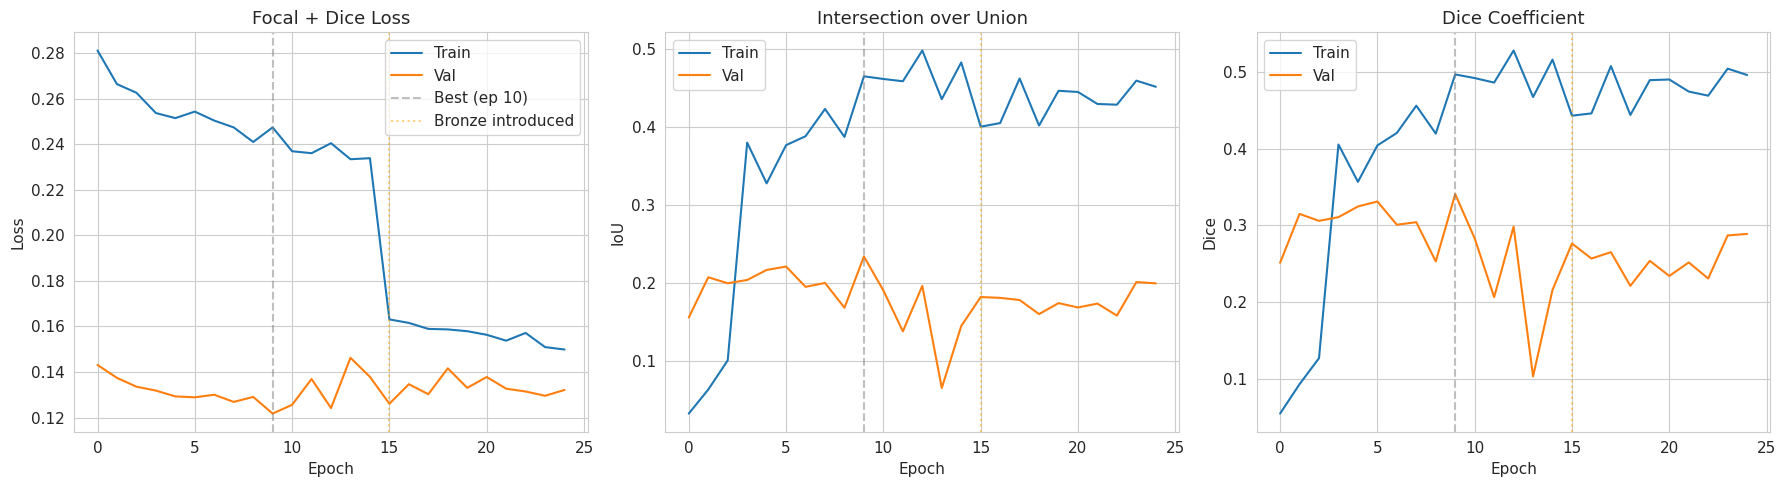

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].axvline(best_epoch - 1, color="gray", ls="--", alpha=0.5, label=f"Best (ep {best_epoch})")
if cfg.CURRICULUM_EPOCH < len(history["train_loss"]):
    axes[0].axvline(cfg.CURRICULUM_EPOCH, color="orange", ls=":", alpha=0.5, label="Bronze introduced")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Focal + Dice Loss"); axes[0].legend()

# IoU
axes[1].plot(history["train_iou"], label="Train")
axes[1].plot(history["val_iou"], label="Val")
axes[1].axvline(best_epoch - 1, color="gray", ls="--", alpha=0.5)
if cfg.CURRICULUM_EPOCH < len(history["train_iou"]):
    axes[1].axvline(cfg.CURRICULUM_EPOCH, color="orange", ls=":", alpha=0.5)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("IoU")
axes[1].set_title("Intersection over Union"); axes[1].legend()

# Dice
axes[2].plot(history["train_dice"], label="Train")
axes[2].plot(history["val_dice"], label="Val")
axes[2].axvline(best_epoch - 1, color="gray", ls="--", alpha=0.5)
if cfg.CURRICULUM_EPOCH < len(history["train_dice"]):
    axes[2].axvline(cfg.CURRICULUM_EPOCH, color="orange", ls=":", alpha=0.5)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Dice")
axes[2].set_title("Dice Coefficient"); axes[2].legend()

plt.tight_layout(); plt.show()


# Phase 4: Test set evaluation


In [11]:
# ============================================================================
# TEST-TIME AUGMENTATION (Run 2, §5)
# ============================================================================

import torchvision.transforms.functional as TF

def tta_predict(model, image, device):
    """
    Average predictions across 4 rotations × 2 flips = 8 augmentations.
    image: (1, C, H, W) tensor on CPU
    Returns: (1, 1, H, W) averaged probability map
    """
    model.eval()
    preds = []
    with torch.no_grad():
        for k in range(4):                          # 0°, 90°, 180°, 270°
            for flip in [False, True]:
                x = TF.rotate(image, angle=90 * k)
                if flip:
                    x = TF.hflip(x)
                x = x.to(device)
                with autocast():
                    logit = model(x)
                prob = torch.sigmoid(logit)
                # Undo flip and rotation
                if flip:
                    prob = TF.hflip(prob)
                prob = TF.rotate(prob, angle=-90 * k)
                preds.append(prob.cpu())
    return torch.stack(preds).mean(dim=0)


# ============================================================================
# LOAD BEST MODEL + EVALUATE WITH TTA
# ============================================================================

ckpt = torch.load(os.path.join(cfg.CHECKPOINT_DIR, "best_model.pth"), map_location=cfg.DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded best model from epoch {ckpt['epoch']}")

# Standard evaluation (no TTA) for comparison
test_loss, test_m = validate(model, test_loader, criterion, cfg.DEVICE)

print(f"\nTest set results — standard inference (blocks {cfg.TEST_BLOCKS}):")
print(f"  Loss:      {test_loss:.4f}")
print(f"  IoU:       {test_m['iou']:.4f}")
print(f"  Dice:      {test_m['dice']:.4f}")
print(f"  Precision: {test_m['precision']:.4f}")
print(f"  Recall:    {test_m['recall']:.4f}")

# TTA evaluation
print(f"\nRunning TTA evaluation (8× augmentations)...")
model.eval()
tta_iou_sum, tta_dice_sum, tta_prec_sum, tta_rec_sum = 0.0, 0.0, 0.0, 0.0
n_tta = 0

for i in tqdm(range(len(test_ds)), desc="  TTA eval"):
    img, mask, _ = test_ds[i]
    prob = tta_predict(model, img.unsqueeze(0), cfg.DEVICE)  # (1, 1, H, W)
    pred = (prob > 0.5).float()
    mask_t = mask.unsqueeze(0)  # (1, 1, H, W)

    inter = (pred * mask_t).sum()
    p_sum = pred.sum()
    t_sum = mask_t.sum()
    union = p_sum + t_sum - inter

    tta_iou_sum  += (inter + 1e-7) / (union + 1e-7)
    tta_dice_sum += (2 * inter + 1e-7) / (p_sum + t_sum + 1e-7)
    tta_prec_sum += (inter + 1e-7) / (p_sum + 1e-7)
    tta_rec_sum  += (inter + 1e-7) / (t_sum + 1e-7)
    n_tta += 1

print(f"\nTest set results — TTA (blocks {cfg.TEST_BLOCKS}):")
print(f"  IoU:       {tta_iou_sum / n_tta:.4f}")
print(f"  Dice:      {tta_dice_sum / n_tta:.4f}")
print(f"  Precision: {tta_prec_sum / n_tta:.4f}")
print(f"  Recall:    {tta_rec_sum / n_tta:.4f}")

print(f"\nPer-block breakdown (standard):")
for block_id in cfg.TEST_BLOCKS:
    bdf = test_df[test_df["Block_id"] == block_id]
    bds = MelusiTileDataset(bdf, cfg, transform=val_transform)
    bl = DataLoader(bds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0)
    _, bm = validate(model, bl, criterion, cfg.DEVICE)
    print(f"  {block_id}: IoU={bm['iou']:.4f}  Dice={bm['dice']:.4f}  "
          f"Prec={bm['precision']:.4f}  Rec={bm['recall']:.4f}")


Loaded best model from epoch 10



Test set results — standard inference (blocks ['block_1', 'block_11']):
  Loss:      0.1217
  IoU:       0.3130
  Dice:      0.4018
  Precision: 0.3908
  Recall:    0.6972

Running TTA evaluation (8× augmentations)...


  TTA eval: 100%|██████████| 703/703 [01:28<00:00,  7.96it/s]



Test set results — TTA (blocks ['block_1', 'block_11']):
  IoU:       0.3524
  Dice:      0.4404
  Precision: 0.4340
  Recall:    0.7027

Per-block breakdown (standard):


  block_1: IoU=0.0823  Dice=0.1249  Prec=0.1047  Rec=0.8554


  block_11: IoU=0.3363  Dice=0.4278  Prec=0.4196  Rec=0.6874


## Prediction overlays — test set samples


In [12]:
import matplotlib.pyplot as plt

model.eval()
np.random.seed(42)
sample_idx = np.random.choice(len(test_ds), size=min(8, len(test_ds)), replace=False)

fig, axes = plt.subplots(len(sample_idx), 4, figsize=(20, 5 * len(sample_idx)))
if len(sample_idx) == 1:
    axes = axes[np.newaxis, :]

for i, idx in enumerate(sample_idx):
    img, mask, _ = test_ds[idx]

    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(cfg.DEVICE))
        pred = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze()

    # De-normalise for display
    img_np = img.permute(1, 2, 0).numpy()
    img_np = img_np * np.array(cfg.IMG_STD) + np.array(cfg.IMG_MEAN)
    img_np = np.clip(img_np, 0, 1)

    mask_np = mask.squeeze().numpy()
    pred_np = pred.numpy()

    axes[i, 0].imshow(img_np); axes[i, 0].set_title("RGB")
    axes[i, 1].imshow(mask_np, cmap="Reds", vmin=0, vmax=1); axes[i, 1].set_title("Ground truth")
    axes[i, 2].imshow(pred_np, cmap="Blues", vmin=0, vmax=1); axes[i, 2].set_title("Prediction")

    # TP/FN/FP overlay
    overlay = np.zeros((*mask_np.shape, 3))
    overlay[..., 1] = pred_np * mask_np           # TP = green
    overlay[..., 0] = mask_np * (1 - pred_np)     # FN = red
    overlay[..., 2] = pred_np * (1 - mask_np)     # FP = blue
    axes[i, 3].imshow(img_np)
    axes[i, 3].imshow(overlay, alpha=0.5)
    axes[i, 3].set_title("TP(green) FN(red) FP(blue)")

    for ax in axes[i]: ax.axis("off")

plt.tight_layout(); plt.show()


Output hidden; open in https://colab.research.google.com to view.

# Phase 5: Generate dwelling counts for RF pipeline

Run inference on all tiles, aggregate predicted dwelling area per block.
Produces `unet_block_predictions.csv` and `unet_tile_predictions.csv`
for Random Forest regression.


In [ ]:
# ============================================================================
# PHASE 5: DWELLING COUNTS FOR RF PIPELINE (using TTA)
# ============================================================================

model.eval()

all_tiles = pd.read_csv(cfg.TILE_INDEX)
all_tiles = all_tiles[all_tiles["has_mask"] == True].copy()

all_ds = MelusiTileDataset(all_tiles, cfg, transform=val_transform)

# Use TTA for final dwelling count predictions
print("Running TTA inference on all tiles for dwelling counts...")
pred_px = []
for i in tqdm(range(len(all_ds)), desc="TTA inference"):
    img, _, _ = all_ds[i]
    prob = tta_predict(model, img.unsqueeze(0), cfg.DEVICE)  # (1, 1, H, W)
    pred = (prob > 0.5).float()
    pred_px.append(pred.sum().item())

all_tiles["pred_dwelling_px"] = pred_px[:len(all_tiles)]
all_tiles["pred_dwelling_frac"] = all_tiles["pred_dwelling_px"] / (cfg.TILE_SIZE ** 2)

block_summary = (
    all_tiles.groupby("Block_id")
    .agg(
        n_tiles=("tile_id", "count"),
        label_dwelling_px=("dwelling_pixel_count", "sum"),
        pred_dwelling_px=("pred_dwelling_px", "sum"),
    )
    .reset_index()
)
block_summary["label_area_m2"] = block_summary["label_dwelling_px"] * (cfg.PIXEL_SIZE ** 2)
block_summary["pred_area_m2"] = block_summary["pred_dwelling_px"] * (cfg.PIXEL_SIZE ** 2)
block_summary["ratio"] = block_summary["pred_dwelling_px"] / block_summary["label_dwelling_px"].replace(0, np.nan)

print("Block-level dwelling area comparison:")
print(block_summary.to_string(index=False))

block_summary.to_csv(os.path.join(cfg.PROCESSED_DIR, "unet_block_predictions.csv"), index=False)
all_tiles.to_csv(os.path.join(cfg.PROCESSED_DIR, "unet_tile_predictions.csv"), index=False)
print(f"\nSaved: unet_block_predictions.csv, unet_tile_predictions.csv")


Running TTA inference on all tiles for dwelling counts...


TTA inference:  42%|████▏     | 3400/8109 [07:06<10:10,  7.71it/s]

# Phase X: Save and Push

In [ ]:
save_and_push("kc_unet.ipynb", "Finished notebook scaffold")